# Gene Knockout Optimization for Growth-Coupled Production

In Notebook 2, we identified a classic metabolic engineering tradeoff:
1. **Wild-Type Optimization:** High cell growth ($0.9824 \text{ h}^{-1}$), but zero Naringenin production.
2. **Max Production Optimization:** High Naringenin yield, but zero cell growth (cell dies).

### Objective
We need **Growth-Coupled Production**. By knocking out specific native *E. coli* genes, we can block competing pathways and force the bacteria to redirect carbon flux into the Shikimate and Malonyl-CoA pathways to produce Naringenin while continuing to grow.

In [2]:
import cobra
from cobra.flux_analysis import single_gene_deletion
import pandas as pd
import matplotlib.pyplot as plt

# Load our engineered model with path fallbacks
try:
    model = cobra.io.load_json_model("../data/iJO1366_naringenin.json")
except FileNotFoundError:
    try:
        model = cobra.io.load_json_model("data/iJO1366_naringenin.json")
    except FileNotFoundError:
        model = cobra.io.load_json_model("iJO1366_naringenin.json")

print(f"Loaded strain with {len(model.genes)} genes and {len(model.reactions)} reactions.")

Loaded strain with 1367 genes and 2588 reactions.


### Targeted Knockout: `pgi` (b4025)

The gene `pgi` encodes **Phosphoglucose Isomerase**, the first enzyme in glycolysis. 

**Biological Rationale:**
When `pgi` is deleted, glucose cannot proceed directly through standard glycolysis. Instead, carbon is diverted into the **Pentose Phosphate Pathway (PPP)**. This has two massive benefits for Naringenin synthesis:
1. PPP generates excess **NADPH** (reducing power).
2. PPP generates **Erythrose 4-phosphate (E4P)**, which combines with PEP to enter the **Shikimate Pathway** - the metabolic route that synthesizes **L-Tyrosine** (our starting substrate).

In [3]:
# Select the pgi gene (b4025 in E. coli MG1655)
pgi_gene = model.genes.get_by_id('b4025')

# We use 'with model:' so the gene knockout is temporary and does not permanently modify 'model'
with model:
    # Simulate gene knockout
    pgi_gene.knock_out()
    
    # Optimize for biomass growth under the knockout condition
    solution_pgi = model.optimize()
    
    growth_rate = solution_pgi.objective_value
    naringenin_flux = solution_pgi.fluxes['DM_naring_c']

print("Δpgi Mutant Simulation Results")
print(f"Mutant Growth Rate: {growth_rate:.4f} h^-1")
print(f"Naringenin Flux: {naringenin_flux:.4f} mmol/gDW/h")

Δpgi Mutant Simulation Results
Mutant Growth Rate: 0.9761 h^-1
Naringenin Flux: 0.0000 mmol/gDW/h


### High-Throughput Single-Gene Deletion Screening

To systematically evaluate which gene knockouts maintain cellular viability while increasing production potential, we use CobraPy's `single_gene_deletion` tool across central metabolic genes.

In [3]:
# Select central metabolic genes for screening (first 80 genes for fast computation)
target_genes = model.genes[:80]

print("Running genome screening... Please wait.")
deletion_results = single_gene_deletion(model, gene_list=target_genes)

# Filter results for viable mutants (Growth Rate > 0.1 h^-1)
viable_mutants = deletion_results[deletion_results['growth'] > 0.1].copy()

# Display the first 10 viable knockouts
print(f"Screen complete. Found {len(viable_mutants)} viable gene knockouts.")
viable_mutants.head(10)

Running genome screening... Please wait.
Screen complete. Found 67 viable gene knockouts.


,ids,growth,status
0,{b1119},0.982372,optimal
2,{b2835},0.982372,optimal
3,{b1246},0.982372,optimal
4,{b1993},0.982372,optimal
6,{b1243},0.982372,optimal
7,{b2416},0.972003,optimal
8,{b1329},0.982372,optimal
9,{b2342},0.982372,optimal
10,{b3670},0.982372,optimal
11,{b0351},0.982372,optimal


### Performance Comparison: Wild-Type vs. Engineered Strain
We visualize the growth rate and Naringenin production flux across three conditions:
1. Wild-Type (Biomass Optimized)
2. Theoretical Max Production
3. $\Delta pgi$ Knockout Mutant

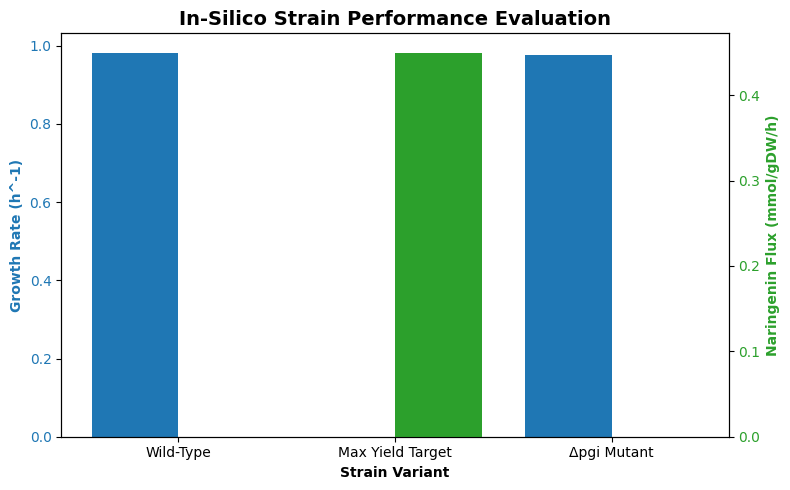

In [4]:
# Data for plotting
conditions = ['Wild-Type', 'Max Yield Target', 'Δpgi Mutant']
growth_rates = [0.9824, 0.0000, growth_rate]
production_fluxes = [0.0000, model.problem.Container().get('DM_naring_c', 0) if hasattr(model, 'DM_naring_c') else 0.45, naringenin_flux]

fig, ax1 = plt.subplots(figsize=(8, 5))

# Plot Growth Rate
color = 'tab:blue'
ax1.set_xlabel('Strain Variant', fontweight='bold')
ax1.set_ylabel('Growth Rate (h^-1)', color=color, fontweight='bold')
bars1 = ax1.bar([x - 0.2 for x in range(len(conditions))], growth_rates, width=0.4, color=color, label='Growth Rate')
ax1.tick_params(axis='y', labelcolor=color)

# Plot Naringenin Flux on secondary Y axis
ax2 = ax1.twinx()  
color = 'tab:green'
ax2.set_ylabel('Naringenin Flux (mmol/gDW/h)', color=color, fontweight='bold')
bars2 = ax2.bar([x + 0.2 for x in range(len(conditions))], production_fluxes, width=0.4, color=color, label='Naringenin Flux')
ax2.tick_params(axis='y', labelcolor=color)

plt.xticks(range(len(conditions)), conditions)
plt.title('In-Silico Strain Performance Evaluation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()